Forecasting Model

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Load data
df = pd.read_csv("/Users/jussaragaspar/Downloads/Final project/time_series_60min_singleindex_filtered.csv")

# Convert timestamp
df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"])
df = df.set_index("utc_timestamp")

# Keep only FRANCE demand first
df_model = df[["FR_load_actual_entsoe_transparency"]].dropna().copy()

In [3]:
# Lag features
df_model["lag_1"] = df_model["FR_load_actual_entsoe_transparency"].shift(1)
df_model["lag_24"] = df_model["FR_load_actual_entsoe_transparency"].shift(24)
df_model["lag_168"] = df_model["FR_load_actual_entsoe_transparency"].shift(168)

# Time features
df_model["hour"] = df_model.index.hour
df_model["dayofweek"] = df_model.index.dayofweek

df_model = df_model.dropna()

In [4]:
X = df_model[["lag_1", "lag_24", "lag_168", "hour", "dayofweek"]]
y = df_model["FR_load_actual_entsoe_transparency"]

In [5]:
split = int(len(df_model) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [6]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [7]:
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
print("MAE:", mae)

MAE: 576.684729693846


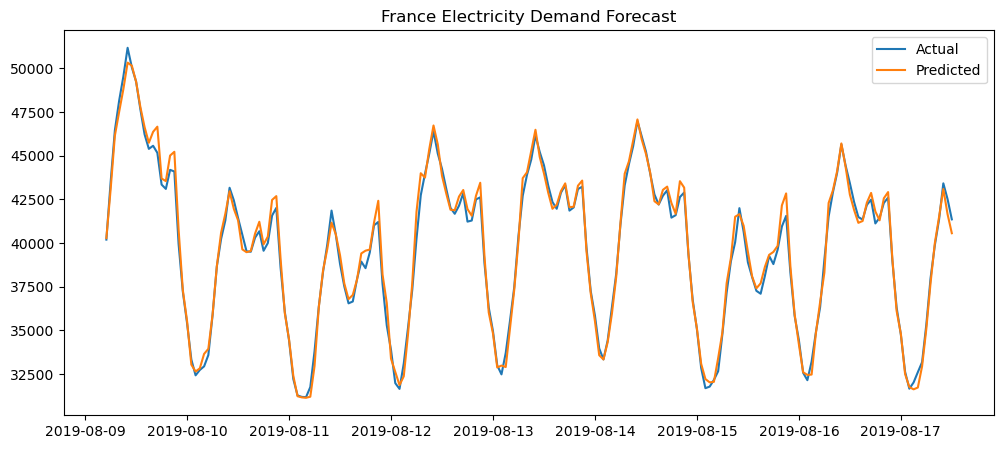

In [16]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index[:200], y_test.iloc[:200], label="Actual")
plt.plot(y_test.index[:200], pred[:200], label="Predicted")
plt.legend()
plt.title("France Electricity Demand Forecast")
plt.show()

<Axes: >

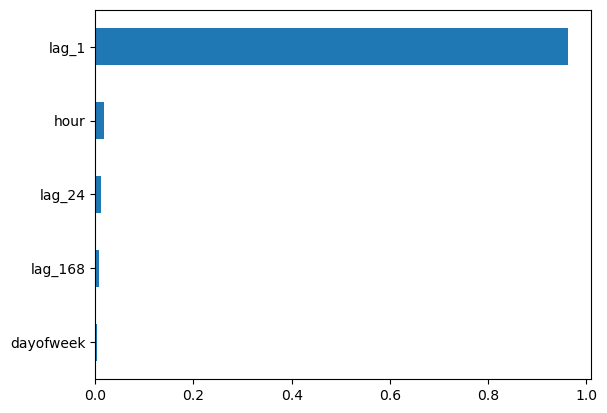

In [9]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh")

**HOUR PATTERN**

<Axes: xlabel='utc_timestamp'>

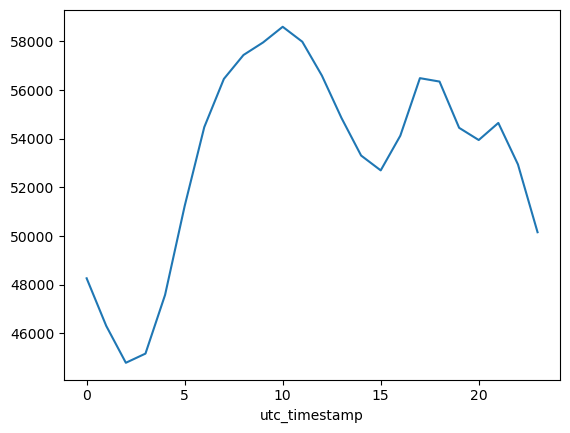

In [11]:
df_model.groupby(df_model.index.hour)["FR_load_actual_entsoe_transparency"].mean().plot()

**DAILY PATTERN**

<Axes: xlabel='utc_timestamp'>

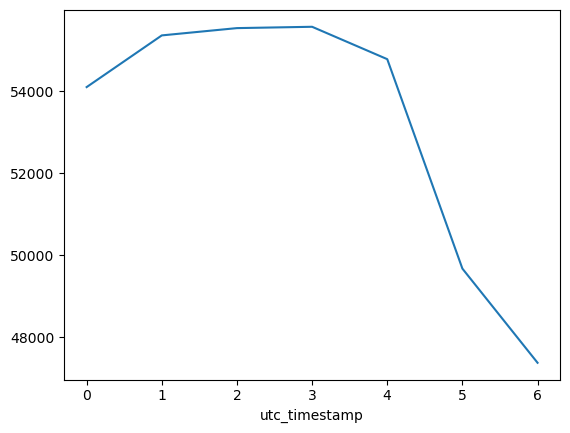

In [12]:
df_model.groupby(df_model.index.dayofweek)["FR_load_actual_entsoe_transparency"].mean().plot()

**WEEKLY PATTERN**

<Axes: xlabel='utc_timestamp'>

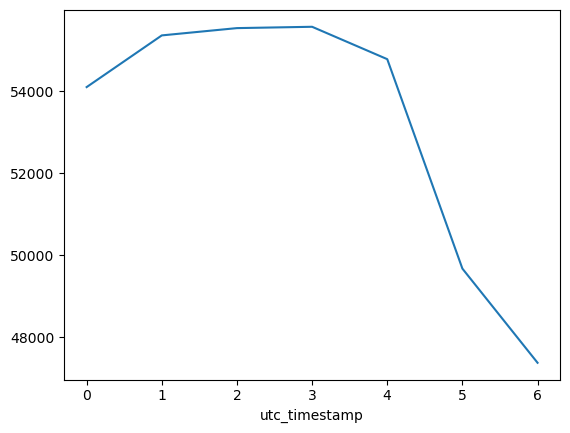

In [13]:
df_model.groupby(df_model.index.dayofweek)["FR_load_actual_entsoe_transparency"].mean().plot()

📍Conclusions:
- Electricity demand shows strong daily seasonality,
with peaks in the morning and evening.
- Lag features (especially lag_24) are highly important,
indicating strong daily repetition patterns.
- The model predicts demand reasonably well,
with an MAE of X Megawatts
